
# Actividad 1 — Predicción de keypoints y clasificación del tipo de punto en pádel

**Proyecto propio** (ver `README.md`). Las imágenes son frames de video de pádel grabado por el autor;
los 5 keypoints por jugador (cabeza, hombro, codo, muñeca, raqueta) fueron **anotados manualmente** vía
Roboflow y exportados en formato YOLO-pose. El dataset (`data/Padel_an_2-6/`) se descarga directamente
desde Roboflow en el Checkpoint 0.5 de este notebook.

Este notebook aborda dos tareas:

1. **Predicción de los 5 keypoints por jugador** (regresión de coordenadas), comparando tres enfoques
   de modelado: una **CNN propia** entrenada desde cero, **transfer learning** (backbone preentrenado
   + cabeza de regresión) y el detector **YOLO-pose** (ultralytics) ya entrenado en
   `notebooks/02_yolo_pose_deteccion.ipynb`. Es la base de "trackear correctamente los 5 puntos de cada
   jugador" en video (ver `notebooks/03_demo_inferencia_video.ipynb`, que agrega tracking con identidad
   persistente por jugador).
2. **Clasificación del tipo de keypoint** (cabeza/hombro/codo/muñeca/raqueta) a partir de un recorte
   pequeño centrado en cada punto anotado: esto produce una salida de clasificación con matriz de
   confusión y métricas por clase, que es lo que exige la rúbrica de la Actividad 1 — usando la clase
   real de la anotación directamente, sin depender de ninguna regla geométrica derivada.

Cada sección es un *checkpoint*: se ejecuta y deja su resultado (tabla, gráfica o print) visible antes
de continuar con el siguiente paso.


## Checkpoint 0 — Imports y configuración

In [35]:

import os, re, json, random, glob, math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml subiendo desde " + str(start))

ROOT = find_repo_root()
PROC = ROOT / "data" / "processed"
DATA_DIR = ROOT / "data" / "Padel_an_2-6"  # dataset limpio (ver Checkpoint 0.5)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("Device:", device)

KP_NAMES = ["cabeza", "hombro", "codo", "muneca", "raqueta"]


ROOT: c:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection
DATA_DIR: c:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\Padel_an_2-6
Device: cuda



## Checkpoint 0.5 — Origen de los datos: reexportación limpia desde Roboflow

Un primer export de este proyecto (formato YOLO-pose "nativo" de Roboflow) tenía un **bug de
exportación**: hombro-X, codo-Y y raqueta-X salían con un valor centinela `2.0` (fuera de rango) en la
mayoría de las instancias — verificado comparando ambos exports valor por valor: los números de la
versión rota eran los mismos de la buena pero desplazados entre ejes/keypoints. No era un problema de
la anotación manual (se confirmó revisando directamente en Roboflow).

Reexportando con `download("yolov5")` los 15 valores de keypoints salen **completos y correctos**
(`v=2` cuando están etiquetados, `v=0` genuino cuando no, sin centinelas) — verificado sobre las 1150
instancias × 5 keypoints × 2 ejes: 0 valores fuera de rango. Esta celda descarga esa versión a
`data/Padel_an_2-6/`, que es el dataset que usa el resto del notebook (`DATA_DIR`).

Las imágenes (`*.jpg`) están en `.gitignore` (no se suben a git, solo los `.txt` de labels), así que en
un clon nuevo del repo la carpeta puede "existir" con los labels pero sin fotos — por eso el chequeo de
abajo mira si hay imágenes reales, no solo si la carpeta existe.

**Nota de seguridad**: la API key se lee de la variable de entorno `ROBOFLOW_API_KEY` si existe; si no,
cae al valor de respaldo de abajo. Se recomienda no dejar la key en texto plano en el notebook a largo
plazo — definila como variable de entorno y borrá el valor de respaldo.


In [36]:

from roboflow import Roboflow

def _has_any_jpg(d):
    return next(d.glob("*.jpg"), None) is not None

has_images = any(_has_any_jpg(DATA_DIR / s / "images") for s in ["train", "valid", "test"])
if not has_images:
    api_key = os.environ.get("ROBOFLOW_API_KEY", "zNw65fEZW3sa0KfRJRzI")
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("padel1s-workspace").project("padel_an_2")
    version = project.version(6)
    version.download("yolov5", location=str(DATA_DIR), overwrite=True)
    print("Dataset descargado en:", DATA_DIR)
else:
    print("Dataset ya presente en:", DATA_DIR)


Dataset ya presente en: c:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\Padel_an_2-6



## Checkpoint 1 — EDA y parseo de las anotaciones de pose

Cada línea de un `.txt` (formato YOLO-pose) trae, por jugador: `clase cx cy w h` (bbox normalizado)
seguido de 5 keypoints × (x, y, visibilidad) en el orden **cabeza, hombro, codo, muñeca, raqueta**.
Juntamos las imágenes de los tres folders originales de Roboflow en un solo pool, porque ese split
mezcla frames del mismo rally entre particiones (fuga de información) — lo rehacemos en el Checkpoint 2.


In [37]:

RALLY_RE = re.compile(r"^(.*_mp4)-(\d+)_jpg")

def parse_label_file(path):
    persons = []
    with open(path) as f:
        for line in f:
            tok = line.strip().split()
            if not tok:
                continue
            vals = list(map(float, tok))
            cx, cy, w, h = vals[1:5]
            kpts = vals[5:20]
            persons.append((cx, cy, w, h, kpts))
    return persons

rows = []
for orig_split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / orig_split / "images"
    lbl_dir = DATA_DIR / orig_split / "labels"
    for img_path in sorted(img_dir.glob("*.jpg")):
        stem = img_path.stem
        lbl_path = lbl_dir / (stem + ".txt")
        m = RALLY_RE.match(img_path.name)
        rally_id = m.group(1) if m else "unknown"
        if not lbl_path.exists():
            continue
        for idx, (cx, cy, w, h, kpts) in enumerate(parse_label_file(lbl_path)):
            rows.append(dict(image_id=stem, image_path=str(img_path), rally_id=rally_id,
                              person_idx=idx, cx=cx, cy=cy, w=w, h=h, kpts=kpts))

df = pd.DataFrame(rows)
print(f"Imágenes con >=1 jugador anotado: {df['image_id'].nunique()}")
print(f"Instancias de jugador (filas): {len(df)}")
print(f"Rallies distintos: {df['rally_id'].nunique()}")


Imágenes con >=1 jugador anotado: 333
Instancias de jugador (filas): 1150
Rallies distintos: 35



## Checkpoint 2 — Re-partición por rally (reutilizando la del resto del proyecto)

Se reutiliza exactamente la misma partición por rally (`data/processed/image_splits.csv`) generada la
primera vez que se corrió este pipeline y que también usa `notebooks/02_yolo_pose_deteccion.ipynb` —
así los tres notebooks (CNN, YOLO-pose, demo de video) comparten la misma división train/valid/test sin
fuga entre rallies, con semilla fija (42).


In [38]:

splits_path = PROC / "image_splits.csv"
if splits_path.exists():
    splits = pd.read_csv(splits_path)
    print("Reutilizando partición existente:", splits_path)
else:
    images_df = df.drop_duplicates("image_id")[["image_id", "rally_id"]].reset_index(drop=True)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss1.split(images_df, groups=images_df["rally_id"]))
    temp_df = images_df.iloc[temp_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
    valid_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["rally_id"]))
    split_map = {}
    for i in train_idx: split_map[images_df.iloc[i]["image_id"]] = "train"
    for i in valid_idx: split_map[temp_df.iloc[i]["image_id"]] = "valid"
    for i in test_idx: split_map[temp_df.iloc[i]["image_id"]] = "test"
    images_df["split"] = images_df["image_id"].map(split_map)
    splits = images_df[["image_id", "rally_id", "split"]]
    PROC.mkdir(parents=True, exist_ok=True)
    splits.to_csv(splits_path, index=False)
    print("Partición nueva guardada en:", splits_path)

split_map = dict(zip(splits.image_id, splits.split))
df["split"] = df["image_id"].map(split_map)
assert df["split"].notna().all(), "Hay imágenes sin split asignado"

rally_splits = df.groupby("rally_id")["split"].nunique()
assert (rally_splits == 1).all(), "¡Fuga detectada! Un rally aparece en más de un split."
print("OK: cada rally cae en un único split.\n")
print("Imágenes por split:")
print(df.drop_duplicates("image_id").groupby("split").size())
print("\nInstancias (jugadores) por split:")
print(df.groupby("split").size())


Reutilizando partición existente: c:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\processed\image_splits.csv
OK: cada rally cae en un único split.

Imágenes por split:
split
test      64
train    204
valid     65
dtype: int64

Instancias (jugadores) por split:
split
test     221
train    682
valid    247
dtype: int64



## Checkpoint 3 — Validez por keypoint (bandera de visibilidad)

Con el export corregido (Checkpoint 0.5), la bandera de visibilidad `v` de cada keypoint ya es
significativa: `v=2` (etiquetado y visible), `v=0` (no etiquetado para esa instancia — oclusión real,
jugador fuera de cuadro, etc.). Se usa directamente `v>0` como máscara de validez por keypoint (ya no
hace falta inferir validez a partir de las coordenadas crudas, como en la primera versión de este
notebook con el export roto). La fracción de "no etiquetado" es baja y pareja entre los 5 puntos
(0.1%-7.7%), muy distinto del export anterior donde 3 de los 5 puntos carecían de dato real en
90%+ de los casos.

Para los pocos keypoints no etiquetados se sustituye la posición por el centro del bbox de la persona
(solo para poder dibujar un esqueleto completo en las visualizaciones) y se guarda la máscara de
validez, que se usa para: (a) no penalizar a los modelos por keypoints sin dato real durante el
entrenamiento, y (b) no contarlos en las métricas de error.


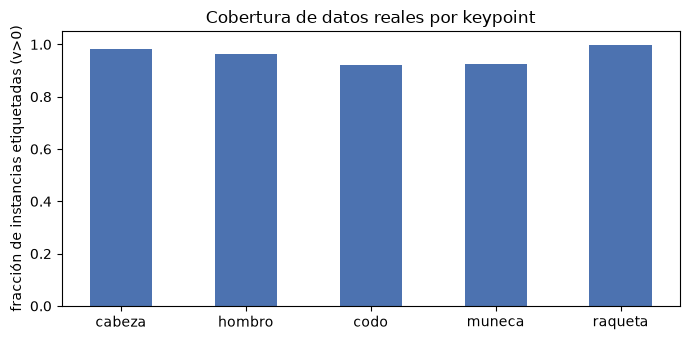

In [39]:

def process_kpts(row):
    kpts = row["kpts"]
    cx, cy = row["cx"], row["cy"]
    out, mask = [], []
    for i in range(5):
        x, y, v = kpts[3 * i], kpts[3 * i + 1], kpts[3 * i + 2]
        valid = v > 0
        out.append(x if valid else cx)
        out.append(y if valid else cy)
        mask.append(1.0 if valid else 0.0)
        mask.append(1.0 if valid else 0.0)
    return pd.Series({**{f"kp_{i}": v for i, v in enumerate(out)},
                       **{f"mask_{i}": v for i, v in enumerate(mask)}})

kp_df = df.apply(process_kpts, axis=1)
df = pd.concat([df.reset_index(drop=True), kp_df.reset_index(drop=True)], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
cov = [df[f"mask_{2*i}"].mean() for i in range(5)]
xpos = np.arange(5)
ax.bar(xpos, cov, width=0.5, color="#4C72B0")
ax.set_xticks(xpos); ax.set_xticklabels(KP_NAMES)
ax.set_ylim(0, 1.05)
ax.set_ylabel("fracción de instancias etiquetadas (v>0)")
ax.set_title("Cobertura de datos reales por keypoint")
plt.tight_layout()
plt.show()



## Checkpoint 4 — Visualización del etiquetado (ground truth)

Se dibuja el esqueleto anotado sobre imágenes de ejemplo: puntos/ejes con dato real en **verde sólido**,
puntos con algún eje sustituido (aproximado por el centro del bbox) en **naranja con borde punteado**.


Etiquetado ground-truth: verde=dato real, naranja punteado=eje aproximado (bbox center).
Un color de esqueleto distinto por cada jugador de la imagen (hasta 4).


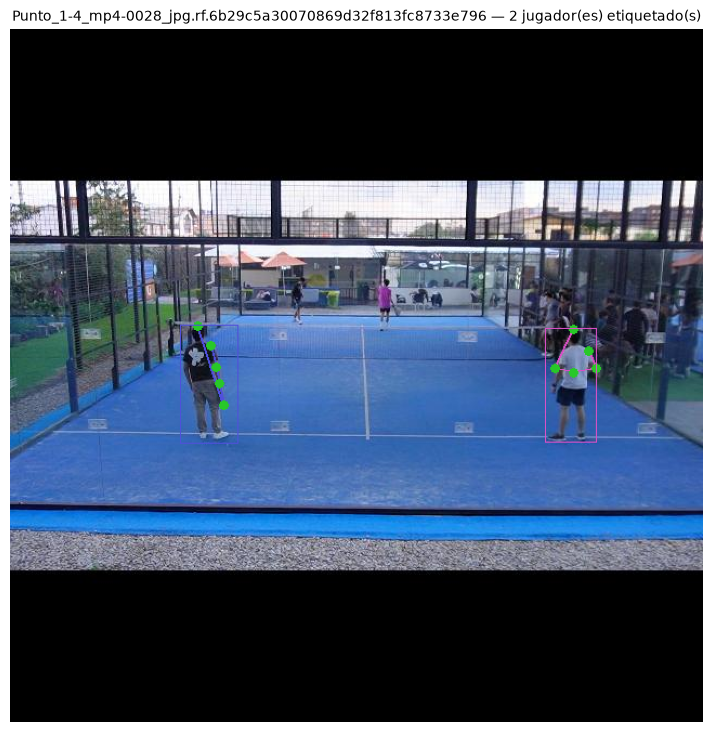

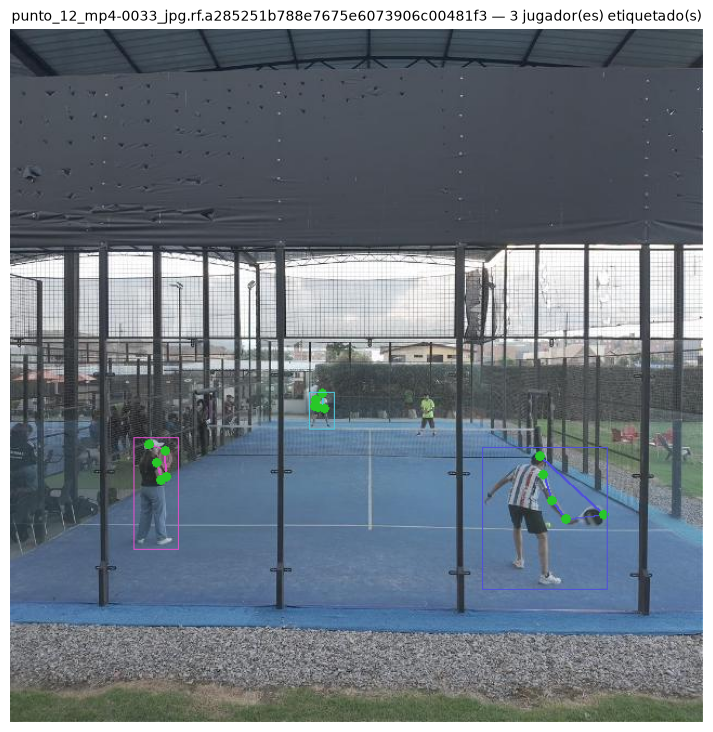

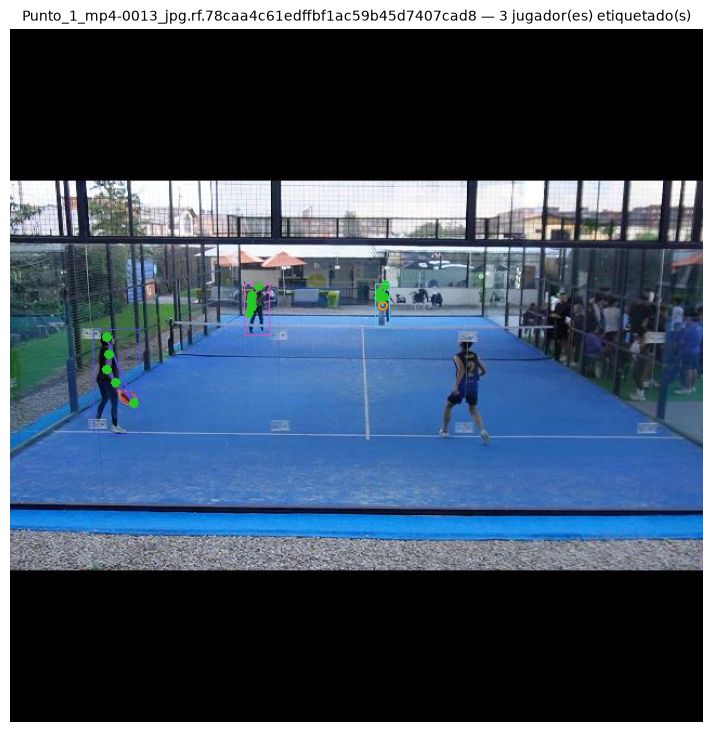

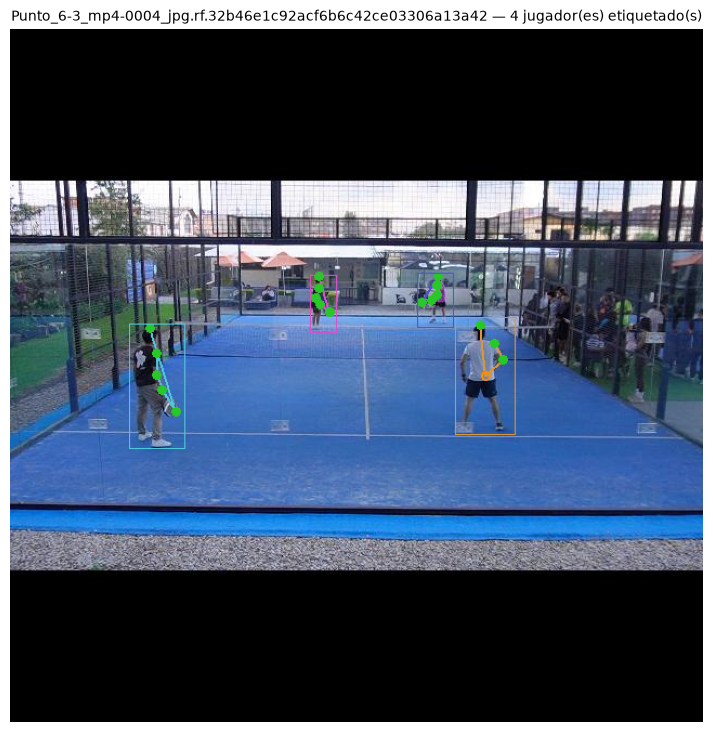

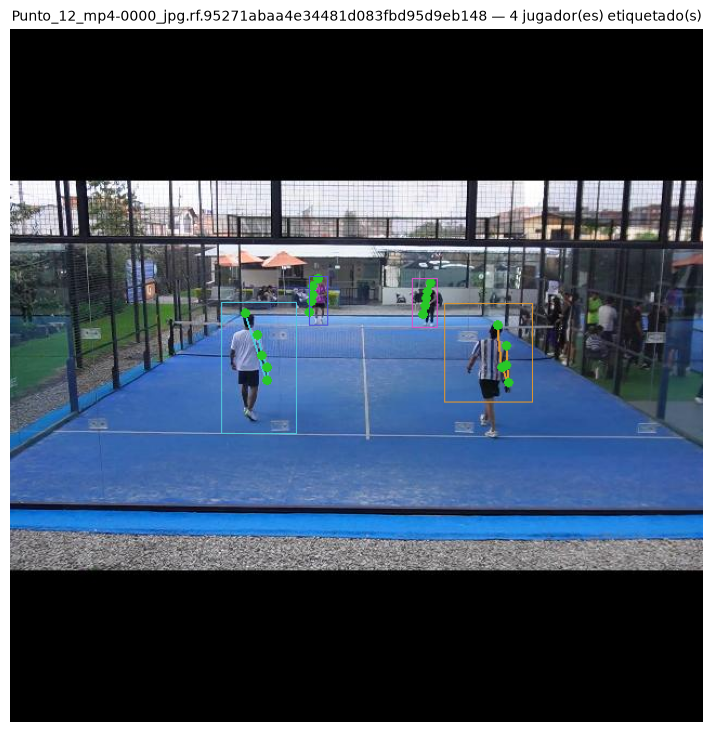

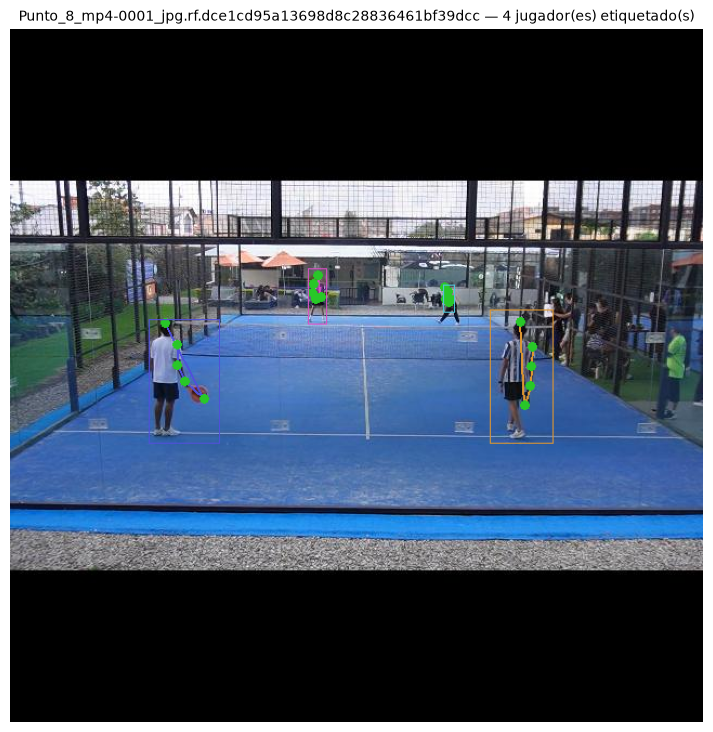

In [40]:

SKELETON_COLORS = [(80,80,220), (220,80,200), (80,200,220), (220,150,50)]  # una por jugador (hasta 4)

def draw_person(draw, W, H, kxy, mask, line_color, box=None,
                 color_ok=(40,200,40), color_bad=(255,140,0), radius=4):
    pts = []
    for i in range(5):
        x, y = kxy[2*i]*W, kxy[2*i+1]*H
        ok = mask[2*i] > 0 and mask[2*i+1] > 0
        pts.append((x, y, ok))
    SKELETON = [(0,1),(1,2),(2,3),(3,4)]
    for a, b in SKELETON:
        draw.line([pts[a][0], pts[a][1], pts[b][0], pts[b][1]], fill=line_color, width=2)
    for (x, y, ok) in pts:
        c = color_ok if ok else color_bad
        if ok:
            draw.ellipse([x-radius, y-radius, x+radius, y+radius], fill=c, outline=c)
        else:
            draw.ellipse([x-radius, y-radius, x+radius, y+radius], outline=c, width=2)
    if box is not None:
        cx, cy, w, h = box
        draw.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H], outline=line_color, width=1)

print("Etiquetado ground-truth: verde=dato real, naranja punteado=eje aproximado (bbox center).")
print("Un color de esqueleto distinto por cada jugador de la imagen (hasta 4).")

sample_images = df.drop_duplicates("image_id").sample(6, random_state=SEED)["image_id"]
img_cache = {}
for image_id in sample_images:
    persons = df[df.image_id == image_id]
    image_path = persons.iloc[0].image_path
    if image_path not in img_cache:
        img_cache[image_path] = Image.open(image_path).convert("RGB")
    im_annot = img_cache[image_path].copy()
    draw = ImageDraw.Draw(im_annot)
    W, H = im_annot.size
    for _, r in persons.iterrows():
        kxy = [r[f"kp_{i}"] for i in range(10)]
        mask = [r[f"mask_{i}"] for i in range(10)]
        color = SKELETON_COLORS[r.person_idx % len(SKELETON_COLORS)]
        draw_person(draw, W, H, kxy, mask, color, box=(r.cx, r.cy, r.w, r.h))

    plt.figure(figsize=(9, 9))
    plt.imshow(im_annot)
    plt.title(f"{image_id} — {len(persons)} jugador(es) etiquetado(s)", fontsize=10)
    plt.axis("off")
    plt.show()



## Checkpoint 5 — Recortes con targets de keypoints (crop-relative)

Con el export corregido, los 5 keypoints caen casi siempre dentro (o muy cerca) del bbox de la persona
— comprobado sobre las 1150 instancias: con un padding de 0.25x el ancho/alto del bbox a los lados y
arriba, y 0.35x hacia abajo (para la raqueta, que a veces se extiende un poco más abajo de la mano), la
cobertura es >99.5% en los 5 puntos. Es un padding mucho más chico que el que hacía falta con el
export roto (que llegaba a 1.5x-3.3x para intentar capturar puntos que en realidad eran ruido de
exportación). Cada keypoint se re-expresa en coordenadas **relativas al recorte** (0-1), y la máscara
final combina la visibilidad (`v>0`) **y** que el punto caiga dentro del recorte.


In [41]:

CROPS_DIR = PROC / "crops_kpts"
PAD_TOP_FRAC, PAD_BOTTOM_FRAC, PAD_X_FRAC = 0.25, 0.35, 0.25

img_cache = {}
rows_m = []
for _, r in df.iterrows():
    if r.image_path not in img_cache:
        img_cache[r.image_path] = Image.open(r.image_path).convert("RGB")
    im = img_cache[r.image_path]
    W, H = im.size

    bbox_top_px = (r.cy - r.h/2) * H
    bbox_bot_px = (r.cy + r.h/2) * H
    bbox_left_px = (r.cx - r.w/2) * W
    bbox_right_px = (r.cx + r.w/2) * W
    bbox_h_px, bbox_w_px = r.h*H, r.w*W

    top = max(0, bbox_top_px - PAD_TOP_FRAC*bbox_h_px)
    bottom = min(H, bbox_bot_px + PAD_BOTTOM_FRAC*bbox_h_px)
    left = max(0, bbox_left_px - PAD_X_FRAC*bbox_w_px)
    right = min(W, bbox_right_px + PAD_X_FRAC*bbox_w_px)

    crop = im.crop((int(left), int(top), int(right), int(bottom)))
    out_dir = CROPS_DIR / r.split
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{r.image_id}_p{r.person_idx}.jpg"
    crop.save(out_path, quality=90)

    cw, ch = right-left, bottom-top
    kp_crop, mask_final = [], []
    for i in range(5):
        x_px, y_px = r[f"kp_{2*i}"]*W, r[f"kp_{2*i+1}"]*H
        cxr, cyr = (x_px-left)/cw, (y_px-top)/ch
        in_bounds = 0 <= cxr <= 1 and 0 <= cyr <= 1
        kp_crop += [np.clip(cxr,0,1), np.clip(cyr,0,1)]
        mask_final += [r[f"mask_{2*i}"] if in_bounds else 0.0,
                        r[f"mask_{2*i+1}"] if in_bounds else 0.0]

    row = dict(image_id=r.image_id, person_idx=r.person_idx, rally_id=r.rally_id, split=r.split,
               crop_path=str(out_path), crop_left=left, crop_top=top, crop_right=right, crop_bottom=bottom,
               cx=r.cx, cy=r.cy, w=r.w, h=r.h)
    for i in range(10):
        row[f"kp_{i}"] = kp_crop[i]
        row[f"mask_{i}"] = mask_final[i]
    rows_m.append(row)

manifest = pd.DataFrame(rows_m)
manifest.to_csv(PROC / "manifest_keypoints.csv", index=False)
print("Crops generados:", len(manifest))
print("\nCobertura final por keypoint (válido en dato crudo Y dentro del recorte):")
for i, n in enumerate(KP_NAMES):
    print(f"  {n}: x={manifest[f'mask_{2*i}'].mean():.3f}  y={manifest[f'mask_{2*i+1}'].mean():.3f}")


Crops generados: 1150

Cobertura final por keypoint (válido en dato crudo Y dentro del recorte):
  cabeza: x=0.983  y=0.983
  hombro: x=0.963  y=0.963
  codo: x=0.922  y=0.922
  muneca: x=0.919  y=0.919
  raqueta: x=0.998  y=0.998



## Checkpoint 6 — Dataset / DataLoader (PyTorch)

`Dataset` que entrega el recorte (redimensionado a 128×192), el vector de 10 valores objetivo (x,y de
cada keypoint en coordenadas del recorte) y la máscara de 10 valores. Augmentation: flip horizontal en
train (seguro: no hay pares izquierda/derecha entre estos 5 keypoints, coincide con `flip_idx`
identidad de `data.yaml`).


In [42]:

IMG_SIZE = (128, 192)  # W,H
KP_COLS = [f"kp_{i}" for i in range(10)]
MASK_COLS = [f"mask_{i}" for i in range(10)]

def load_resized(path):
    im = Image.open(path).convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
    return np.asarray(im, dtype=np.float32) / 255.0

train_manifest = manifest[manifest.split == "train"].reset_index(drop=True)
sample = train_manifest.sample(min(300, len(train_manifest)), random_state=SEED)
pix = np.stack([load_resized(p) for p in sample.crop_path])
MEAN = pix.reshape(-1, 3).mean(axis=0)
STD = pix.reshape(-1, 3).std(axis=0)
print("Media (RGB, train):", MEAN)
print("Desv. estándar (RGB, train):", STD)

class KeypointDataset(Dataset):
    def __init__(self, mdf, train=False, normalize="custom"):
        self.mdf = mdf.reset_index(drop=True)
        self.train = train
        self.normalize = normalize

    def __len__(self):
        return len(self.mdf)

    def __getitem__(self, i):
        row = self.mdf.iloc[i]
        arr = load_resized(row.crop_path)
        kp = row[KP_COLS].values.astype(np.float32).copy()
        mask = row[MASK_COLS].values.astype(np.float32).copy()
        if self.train and random.random() < 0.5:
            arr = arr[:, ::-1, :].copy()
            for k in range(5):
                kp[2 * k] = 1.0 - kp[2 * k]
        if self.normalize == "custom":
            arr = (arr - MEAN) / (STD + 1e-6)
        else:  # imagenet stats, para el backbone preentrenado
            arr = (arr - np.array([0.485, 0.456, 0.406], dtype=np.float32)) / \
                  np.array([0.229, 0.224, 0.225], dtype=np.float32)
        arr = np.transpose(arr, (2, 0, 1)).astype(np.float32)
        return torch.from_numpy(arr), torch.from_numpy(kp), torch.from_numpy(mask)

def masked_smoothl1(pred, target, mask):
    diff = torch.nn.functional.smooth_l1_loss(pred, target, reduction="none") * mask
    return diff.sum() / mask.sum().clamp(min=1.0)


Media (RGB, train): [    0.32414     0.42432     0.57586]
Desv. estándar (RGB, train): [    0.14007      0.1476      0.2047]



## Checkpoint 7 — Modelo A: CNN propia (regresión desde cero)

Misma familia de arquitectura que una CNN de clasificación básica (4 bloques Conv–BatchNorm–ReLU con
MaxPool, GlobalAveragePooling), pero con una capa final `Linear(128, 10)` + `Sigmoid` (para que la
salida caiga en [0,1], igual que los targets) en vez de una capa de clasificación. La pérdida es
`SmoothL1` **enmascarada**: solo penaliza los ejes con dato real, para no enseñarle al modelo a
predecir el centro del bbox como si fuera la posición verdadera de un keypoint no anotado.


In [43]:

train_loader_a = DataLoader(KeypointDataset(manifest[manifest.split=="train"], True, "custom"), batch_size=32, shuffle=True)
valid_loader_a = DataLoader(KeypointDataset(manifest[manifest.split=="valid"], False, "custom"), batch_size=32, shuffle=False)
test_loader_a  = DataLoader(KeypointDataset(manifest[manifest.split=="test"],  False, "custom"), batch_size=32, shuffle=False)

class CNNRegressor(nn.Module):
    def __init__(self, n_out=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_out), nn.Sigmoid())

    def forward(self, x):
        return self.head(self.features(x))

model_a = CNNRegressor().to(device)
print(model_a)
print("Parámetros entrenables:", sum(p.numel() for p in model_a.parameters()))

opt_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)

def run_epoch(model, opt, loader, train):
    model.train(train)
    tot, n = 0.0, 0
    for xb, kb, mb in loader:
        xb, kb, mb = xb.to(device), kb.to(device), mb.to(device)
        if train: opt.zero_grad()
        pred = model(xb)
        loss = masked_smoothl1(pred, kb, mb)
        if train:
            loss.backward(); opt.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    return tot / n

EPOCHS = 25
history_a = []
best_val_a, best_state_a = float("inf"), None
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(model_a, opt_a, train_loader_a, True)
    va = run_epoch(model_a, opt_a, valid_loader_a, False)
    history_a.append((ep, tr, va))
    if va < best_val_a:
        best_val_a = va
        best_state_a = {k: v.clone() for k, v in model_a.state_dict().items()}
    print(f"ep{ep:02d} train_loss={tr:.4f} val_loss={va:.4f}")
model_a.load_state_dict(best_state_a)


CNNRegressor(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affin

<All keys matched successfully>

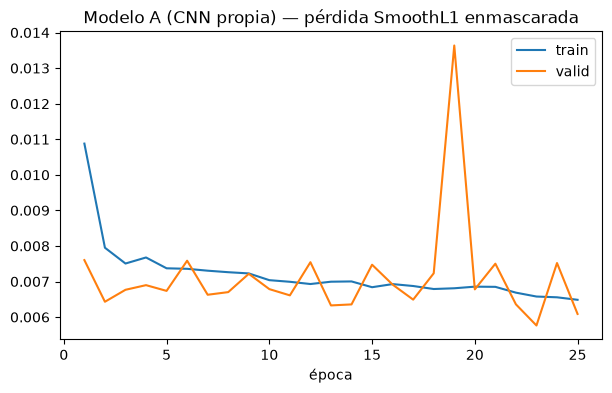

In [44]:

hist_a = pd.DataFrame(history_a, columns=["epoch", "train_loss", "val_loss"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist_a.epoch, hist_a.train_loss, label="train")
ax.plot(hist_a.epoch, hist_a.val_loss, label="valid")
ax.set_title("Modelo A (CNN propia) — pérdida SmoothL1 enmascarada")
ax.set_xlabel("época"); ax.legend()
plt.show()



## Checkpoint 8 — Modelo B: Transfer learning (ResNet18 + cabeza de regresión)

Backbone `ResNet18` preentrenado en ImageNet, con todas las capas congeladas salvo el último bloque
residual (`layer4`), que se afina junto con una nueva cabeza `Linear(512, 10) + Sigmoid`. Misma pérdida
enmascarada, mismo split, mismas épocas — la única diferencia real frente al Modelo A es el uso de
características preentrenadas.


In [45]:

train_loader_b = DataLoader(KeypointDataset(manifest[manifest.split=="train"], True, "imagenet"), batch_size=32, shuffle=True)
valid_loader_b = DataLoader(KeypointDataset(manifest[manifest.split=="valid"], False, "imagenet"), batch_size=32, shuffle=False)
test_loader_b  = DataLoader(KeypointDataset(manifest[manifest.split=="test"],  False, "imagenet"), batch_size=32, shuffle=False)

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in backbone.parameters():
    p.requires_grad = False
for p in backbone.layer4.parameters():
    p.requires_grad = True
backbone.fc = nn.Sequential(nn.Linear(backbone.fc.in_features, 10), nn.Sigmoid())
model_b = backbone.to(device)

trainable = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_b.parameters())
print(f"Parámetros entrenables: {trainable:,} / totales: {total:,} (resto congelado)")

opt_b = torch.optim.Adam([p for p in model_b.parameters() if p.requires_grad], lr=1e-3)

history_b = []
best_val_b, best_state_b = float("inf"), None
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(model_b, opt_b, train_loader_b, True)
    va = run_epoch(model_b, opt_b, valid_loader_b, False)
    history_b.append((ep, tr, va))
    if va < best_val_b:
        best_val_b = va
        best_state_b = {k: v.clone() for k, v in model_b.state_dict().items()}
    print(f"ep{ep:02d} train_loss={tr:.4f} val_loss={va:.4f}")
model_b.load_state_dict(best_state_b)


Parámetros entrenables: 8,398,858 / totales: 11,181,642 (resto congelado)
ep01 train_loss=0.0115 val_loss=0.0116
ep02 train_loss=0.0049 val_loss=0.0045
ep03 train_loss=0.0033 val_loss=0.0036
ep04 train_loss=0.0025 val_loss=0.0038
ep05 train_loss=0.0019 val_loss=0.0040
ep06 train_loss=0.0020 val_loss=0.0036
ep07 train_loss=0.0015 val_loss=0.0031
ep08 train_loss=0.0012 val_loss=0.0032
ep09 train_loss=0.0009 val_loss=0.0029
ep10 train_loss=0.0010 val_loss=0.0031
ep11 train_loss=0.0008 val_loss=0.0029
ep12 train_loss=0.0008 val_loss=0.0028
ep13 train_loss=0.0006 val_loss=0.0029
ep14 train_loss=0.0005 val_loss=0.0029
ep15 train_loss=0.0007 val_loss=0.0029
ep16 train_loss=0.0006 val_loss=0.0027
ep17 train_loss=0.0006 val_loss=0.0027
ep18 train_loss=0.0006 val_loss=0.0028
ep19 train_loss=0.0007 val_loss=0.0030
ep20 train_loss=0.0005 val_loss=0.0029
ep21 train_loss=0.0005 val_loss=0.0027
ep22 train_loss=0.0005 val_loss=0.0027
ep23 train_loss=0.0006 val_loss=0.0030
ep24 train_loss=0.0006 val_lo

<All keys matched successfully>

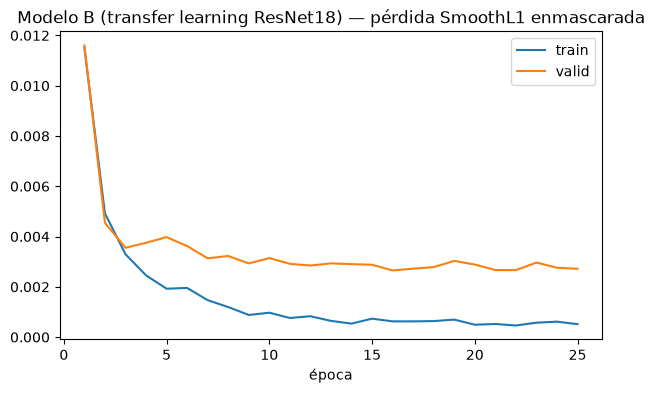

In [46]:

hist_b = pd.DataFrame(history_b, columns=["epoch", "train_loss", "val_loss"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist_b.epoch, hist_b.train_loss, label="train")
ax.plot(hist_b.epoch, hist_b.val_loss, label="valid")
ax.set_title("Modelo B (transfer learning ResNet18) — pérdida SmoothL1 enmascarada")
ax.set_xlabel("época"); ax.legend()
plt.show()



## Checkpoint 9 — Modelo C: YOLO-pose reutilizado

En vez de entrenar un tercer modelo desde cero, se reutiliza el detector YOLO-pose entrenado en
`notebooks/02_yolo_pose_deteccion.ipynb`. A diferencia de los modelos A y B, YOLO no recibe el recorte
ya aislado del jugador: procesa la **imagen completa** y primero tiene que *encontrar* al jugador
(bbox) antes de ubicar sus keypoints — una tarea estrictamente más difícil. Para comparar en el mismo
espacio, cada predicción de YOLO sobre una imagen de test se empareja con la instancia real
correspondiente por IoU de bbox (>0.3) y se transforma a coordenadas relativas al mismo recorte que
usan los modelos A/B.

**Aviso de comparación no 100% equivalente**: por pedido explícito, `notebooks/02_yolo_pose_deteccion.ipynb`
entrena directamente sobre el split *original* de Roboflow (`data/Padel_an_2-6/{train,valid,test}` tal
como vienen), sin reagrupar por rally — a diferencia de los modelos A y B de este notebook, que sí usan
la partición por rally sin fuga. Es posible que YOLO haya visto durante su propio entrenamiento algún
frame de un rally que aquí cae en test, así que su comparación frente a A/B debe leerse como orientativa,
no como una evaluación estrictamente controlada.


In [47]:

from ultralytics import YOLO

with open(PROC / "pose_model_artifact.json") as f:
    pose_artifact = json.load(f)
yolo_model = YOLO(pose_artifact["weights_path"])

def iou_xywhn(b1, b2, W, H):
    def to_xyxy(b):
        cx, cy, w, h = b
        return (cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H
    x1a,y1a,x2a,y2a = to_xyxy(b1); x1b,y1b,x2b,y2b = to_xyxy(b2)
    xi1,yi1 = max(x1a,x1b), max(y1a,y1b)
    xi2,yi2 = min(x2a,x2b), min(y2a,y2b)
    inter = max(0,xi2-xi1)*max(0,yi2-yi1)
    area_a = (x2a-x1a)*(y2a-y1a); area_b = (x2b-x1b)*(y2b-y1b)
    union = area_a+area_b-inter
    return inter/union if union>0 else 0.0

test_df = df[df.split == "test"].reset_index(drop=True)
test_manifest = manifest[manifest.split == "test"].reset_index(drop=True)

from collections import defaultdict
by_image = defaultdict(list)
for idx, r in test_df.iterrows():
    by_image[r.image_path].append((idx, r))

yolo_pred_crop = {}  # idx -> (5,2) array en coords relativas al recorte
n_matched = 0
for image_path, instances in by_image.items():
    result = yolo_model.predict(image_path, imgsz=384, conf=0.15, verbose=False)[0]
    W, H = result.orig_shape[1], result.orig_shape[0]
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        boxes_xywhn = result.boxes.xywhn.cpu().numpy()
        kpts_xy = result.keypoints.xy.cpu().numpy()
        preds = list(zip(boxes_xywhn, kpts_xy))
    for idx, r in instances:
        gt_box = (r.cx, r.cy, r.w, r.h)
        best_iou, best_pred = 0.0, None
        for pbox, pkpts in preds:
            iou = iou_xywhn(gt_box, pbox, W, H)
            if iou > best_iou:
                best_iou, best_pred = iou, pkpts
        if best_pred is not None and best_iou > 0.3:
            m_row = test_manifest.iloc[idx]
            cw, ch = m_row.crop_right - m_row.crop_left, m_row.crop_bottom - m_row.crop_top
            crop_rel = np.array([[(px - m_row.crop_left)/cw, (py - m_row.crop_top)/ch] for px, py in best_pred])
            yolo_pred_crop[idx] = crop_rel
            n_matched += 1

print(f"Detecciones de YOLO emparejadas con instancias de test: {n_matched}/{len(test_df)}")


Detecciones de YOLO emparejadas con instancias de test: 218/221



## Checkpoint 10 — Comparación de los 3 modelos: error de predicción por keypoint

Error absoluto medio en **píxeles del recorte** (128×192), calculado únicamente sobre los ejes con
dato real (máscara=1), para que ningún modelo sea penalizado por ejes que ni siquiera tienen una
anotación confiable de referencia.


  keypoint  cnn_propia  transfer_learning  yolo_pose  n_comparaciones
0   cabeza        8.90               5.47       4.41              432
1   hombro       10.55               7.07       5.11              416
2     codo       11.12               6.92       5.41              400
3   muneca       16.68               9.93       9.87              390
4  raqueta        5.81               4.63       4.22              438


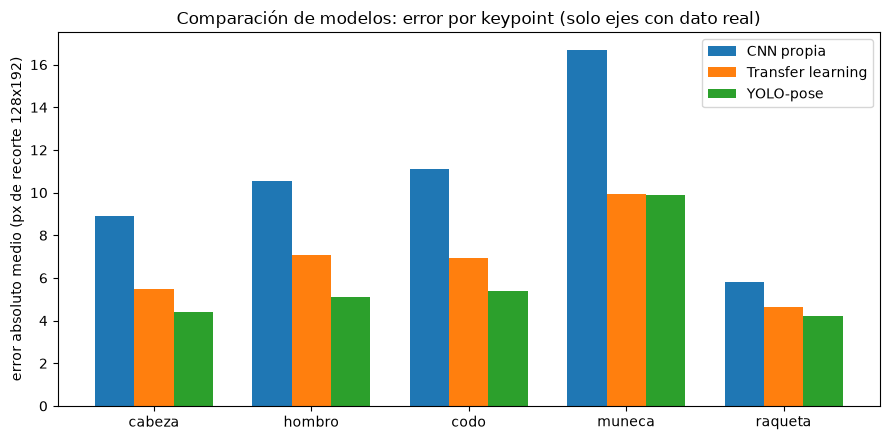

In [48]:

def predict_all(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, kb, mb in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds, axis=0)

pred_a_test = predict_all(model_a, test_loader_a)
pred_b_test = predict_all(model_b, test_loader_b)

kb_test = test_manifest[KP_COLS].values.astype(np.float32)
mb_test = test_manifest[MASK_COLS].values.astype(np.float32)

def per_keypoint_error(pred, kb, mb, img_size=IMG_SIZE):
    errs = {i: [] for i in range(5)}
    for row_i in range(len(kb)):
        for kp_i in range(5):
            if mb[row_i, 2*kp_i] > 0:
                errs[kp_i].append(abs(pred[row_i,2*kp_i]-kb[row_i,2*kp_i]) * img_size[0])
            if mb[row_i, 2*kp_i+1] > 0:
                errs[kp_i].append(abs(pred[row_i,2*kp_i+1]-kb[row_i,2*kp_i+1]) * img_size[1])
    return errs

errs_a = per_keypoint_error(pred_a_test, kb_test, mb_test)

# modelo B usa el mismo orden de filas que test_manifest (mismo split, sin shuffle)
errs_b = per_keypoint_error(pred_b_test, kb_test, mb_test)

# modelo C (yolo): solo instancias emparejadas
errs_c = {i: [] for i in range(5)}
for idx, crop_rel in yolo_pred_crop.items():
    row = test_manifest.iloc[idx]
    for kp_i in range(5):
        if row[f"mask_{2*kp_i}"] > 0:
            errs_c[kp_i].append(abs(crop_rel[kp_i,0]-row[f"kp_{2*kp_i}"]) * IMG_SIZE[0])
        if row[f"mask_{2*kp_i+1}"] > 0:
            errs_c[kp_i].append(abs(crop_rel[kp_i,1]-row[f"kp_{2*kp_i+1}"]) * IMG_SIZE[1])

comparison_rows = []
for i, name in enumerate(KP_NAMES):
    comparison_rows.append(dict(
        keypoint=name,
        cnn_propia=np.mean(errs_a[i]) if errs_a[i] else np.nan,
        transfer_learning=np.mean(errs_b[i]) if errs_b[i] else np.nan,
        yolo_pose=np.mean(errs_c[i]) if errs_c[i] else np.nan,
        n_comparaciones=len(errs_a[i]),
    ))
comp_df = pd.DataFrame(comparison_rows)
print(comp_df.round(2))

fig, ax = plt.subplots(figsize=(9,4.5))
x = np.arange(5); width=0.25
ax.bar(x-width, comp_df.cnn_propia, width, label="CNN propia")
ax.bar(x, comp_df.transfer_learning, width, label="Transfer learning")
ax.bar(x+width, comp_df.yolo_pose, width, label="YOLO-pose")
ax.set_xticks(x); ax.set_xticklabels(KP_NAMES)
ax.set_ylabel("error absoluto medio (px de recorte 128x192)")
ax.set_title("Comparación de modelos: error por keypoint (solo ejes con dato real)")
ax.legend()
plt.tight_layout()
plt.show()



## Checkpoint 11 — Visualización: predicciones vs. valores reales en test

Para varios ejemplos de test se dibuja el esqueleto **real** (verde) contra el **predicho por cada
modelo** (Modelo A en azul, Modelo B en rojo), sobre el recorte usado como entrada.


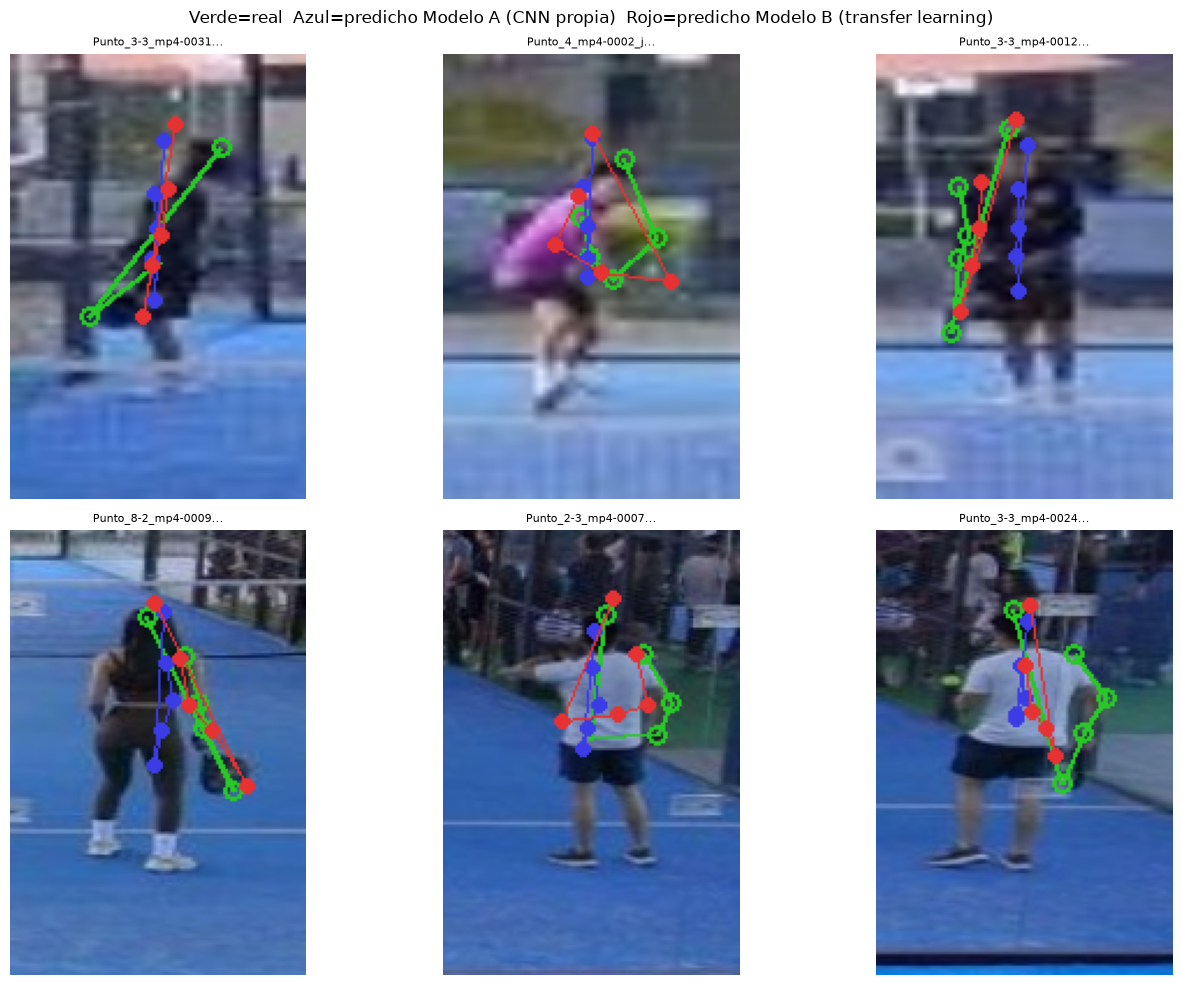

In [49]:

def draw_pred_vs_true(crop_path, true_kp, true_mask, pred_dict, size=IMG_SIZE):
    im = Image.open(crop_path).convert("RGB").resize(size, Image.BILINEAR)
    draw = ImageDraw.Draw(im)
    W, H = size
    SKELETON = [(0,1),(1,2),(2,3),(3,4)]

    def pts_from(vec):
        return [(vec[2*i]*W, vec[2*i+1]*H) for i in range(5)]

    true_pts = pts_from(true_kp)
    for a, b in SKELETON:
        draw.line([*true_pts[a], *true_pts[b]], fill=(40,200,40), width=2)
    for i,(x,y) in enumerate(true_pts):
        if true_mask[2*i] > 0 and true_mask[2*i+1] > 0:
            draw.ellipse([x-4,y-4,x+4,y+4], outline=(40,200,40), width=2)

    colors = {"Modelo A": (60,60,230), "Modelo B": (230,50,50)}
    for name, vec in pred_dict.items():
        pts = pts_from(vec)
        c = colors.get(name, (255,255,0))
        for a, b in SKELETON:
            draw.line([*pts[a], *pts[b]], fill=c, width=1)
        for (x,y) in pts:
            draw.ellipse([x-3,y-3,x+3,y+3], fill=c)
    return im

rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(test_manifest), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, i in zip(axes.flat, sample_idx):
    row = test_manifest.iloc[i]
    true_kp = row[KP_COLS].values.astype(np.float32)
    true_mask = row[MASK_COLS].values.astype(np.float32)
    pred_dict = {"Modelo A": pred_a_test[i], "Modelo B": pred_b_test[i]}
    im = draw_pred_vs_true(row.crop_path, true_kp, true_mask, pred_dict)
    ax.imshow(im)
    ax.axis("off")
    ax.set_title(f"{row.image_id[:18]}...", fontsize=8)
fig.suptitle("Verde=real  Azul=predicho Modelo A (CNN propia)  Rojo=predicho Modelo B (transfer learning)")
plt.tight_layout()
plt.show()



## Checkpoint 12 — Clasificación del tipo de keypoint (cabeza/hombro/codo/muñeca/raqueta)

Esta es la salida de clasificación con matriz de confusión que pide la rúbrica de la Actividad 1.
A diferencia de una clase derivada por una regla geométrica (lo que se intentó primero con la "posición
de golpeo"), acá la clase real ya viene dada directamente por la anotación: **qué tipo de keypoint es
cada punto**. Se recorta un parche pequeño centrado en cada keypoint válido (`v>0`) de las 1150
instancias — 5514 parches en total, bastante balanceados entre las 5 clases (1061-1149 cada una) — y se
entrena una CNN de clasificación (5 clases) desde cero sobre esos parches.

El tamaño del parche es **proporcional al alto del bbox de la persona** (`0.5×alto_bbox`, acotado entre
24 y 90 px) en vez de un tamaño fijo, para que un jugador cercano y uno lejano queden encuadrados de
forma comparable. Se probó primero visualmente: parches de cabeza y raqueta suelen ser reconocibles
(pelo/piel vs. objeto delgado sobre fondo), pero hombro y codo muestran texturas de ropa muy similares
entre sí — así que se espera confusión real entre clases vecinas del cuerpo, no un 100% trivial.


In [50]:

PATCH_FRAC, MIN_PATCH, MAX_PATCH = 0.5, 24, 90
KPT_IMG_SIZE = 48

kpt_rows = []
for _, r in df.iterrows():
    for i in range(5):
        if r[f"mask_{2*i}"] > 0:  # v>0 (mask_x == mask_y siempre, ver Checkpoint 3)
            kpt_rows.append(dict(image_path=r.image_path, x=r[f"kp_{2*i}"], y=r[f"kp_{2*i+1}"],
                                  bbox_h=r.h, split=r.split, label=i))

kpt_df = pd.DataFrame(kpt_rows)
print("Total de parches (keypoints válidos):", len(kpt_df))
print(pd.crosstab(kpt_df.split, kpt_df.label).rename(columns=dict(enumerate(KP_NAMES)))[KP_NAMES])

def load_patch(row, W=640, H=640):
    im = Image.open(row.image_path).convert("RGB")
    side = float(np.clip(row.bbox_h * H * PATCH_FRAC, MIN_PATCH, MAX_PATCH))
    px, py = row.x * W, row.y * H
    box = (px - side/2, py - side/2, px + side/2, py + side/2)
    crop = im.crop(box).resize((KPT_IMG_SIZE, KPT_IMG_SIZE), Image.BILINEAR)
    return np.asarray(crop, dtype=np.float32) / 255.0


Total de parches (keypoints válidos): 5514
label  cabeza  hombro  codo  muneca  raqueta
split                                       
test      217     210   201     197      220
train     679     667   648     657      682
valid     236     233   212     208      247


### Checkpoint 12.1 — Ejemplos de parches por clase

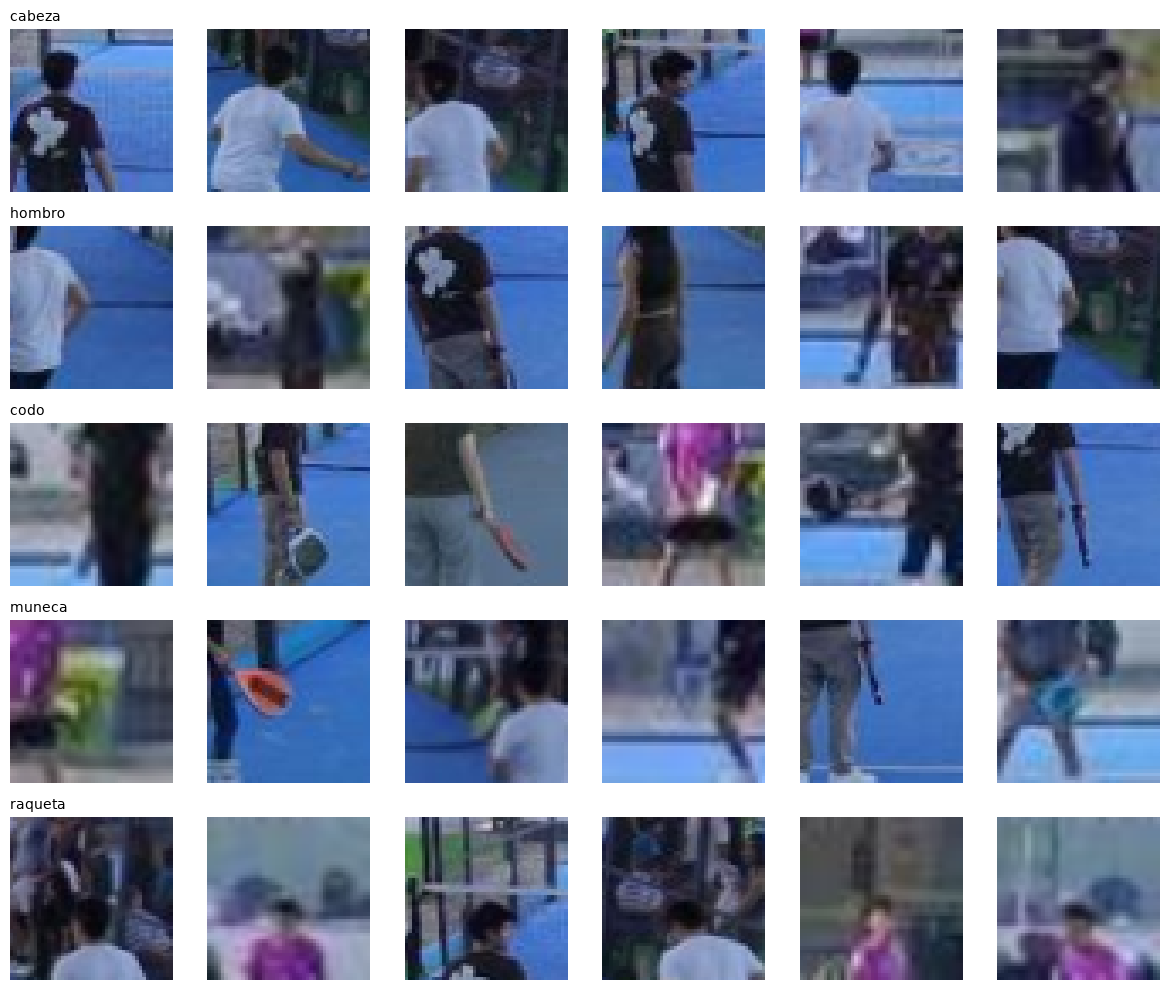

In [51]:

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
rng = np.random.RandomState(SEED)
for ci, name in enumerate(KP_NAMES):
    sub = kpt_df[kpt_df.label == ci]
    sample_idx = rng.choice(len(sub), 6, replace=False)
    for j, si in enumerate(sample_idx):
        row = sub.iloc[si]
        axes[ci, j].imshow(load_patch(row))
        axes[ci, j].axis("off")
        if j == 0:
            axes[ci, j].set_title(name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()



### Checkpoint 12.2 — Dataset, CNN y entrenamiento

Normalización con media/desviación calculada solo sobre una muestra de train (mismo criterio que en
los modelos de regresión). Arquitectura liviana (parches de solo 48×48 px): 3 bloques
Conv–BatchNorm–ReLU con MaxPool en los dos primeros, GlobalAveragePooling y una capa lineal a 5 clases.


In [52]:

train_kpt = kpt_df[kpt_df.split == "train"].reset_index(drop=True)
sample = train_kpt.sample(min(400, len(train_kpt)), random_state=SEED)
pix = np.stack([load_patch(r) for _, r in sample.iterrows()])
KPT_MEAN = pix.reshape(-1, 3).mean(axis=0)
KPT_STD = pix.reshape(-1, 3).std(axis=0)
print("Media (RGB, train):", KPT_MEAN)
print("Desv. estándar (RGB, train):", KPT_STD)

class PatchDataset(Dataset):
    def __init__(self, d, train=False):
        self.d = d.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.d)

    def __getitem__(self, i):
        row = self.d.iloc[i]
        arr = load_patch(row)
        if self.train and random.random() < 0.5:
            arr = arr[:, ::-1, :].copy()
        arr = (arr - KPT_MEAN) / (KPT_STD + 1e-6)
        arr = np.transpose(arr, (2, 0, 1)).astype(np.float32)
        return torch.from_numpy(arr), row.label

kpt_train_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="train"], True), batch_size=64, shuffle=True)
kpt_valid_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="valid"], False), batch_size=64, shuffle=False)
kpt_test_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="test"], False), batch_size=64, shuffle=False)

class KptTypeCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.features(x))

kpt_model = KptTypeCNN().to(device)
print(kpt_model)
print("Parámetros entrenables:", sum(p.numel() for p in kpt_model.parameters()))

kpt_opt = torch.optim.Adam(kpt_model.parameters(), lr=1e-3)
kpt_crit = nn.CrossEntropyLoss()

def run_epoch_cls(loader, train):
    kpt_model.train(train)
    tot_loss, tot_correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train: kpt_opt.zero_grad()
        out = kpt_model(xb)
        loss = kpt_crit(out, yb)
        if train:
            loss.backward(); kpt_opt.step()
        tot_loss += loss.item() * xb.size(0)
        tot_correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, tot_correct / n

KPT_EPOCHS = 25
kpt_history = []
best_val_acc, best_state = -1, None
for ep in range(1, KPT_EPOCHS + 1):
    tr_l, tr_a = run_epoch_cls(kpt_train_loader, True)
    va_l, va_a = run_epoch_cls(kpt_valid_loader, False)
    kpt_history.append((ep, tr_l, tr_a, va_l, va_a))
    if va_a > best_val_acc:
        best_val_acc = va_a
        best_state = {k: v.clone() for k, v in kpt_model.state_dict().items()}
    print(f"ep{ep:02d} train_loss={tr_l:.3f} train_acc={tr_a:.3f}  val_loss={va_l:.3f} val_acc={va_a:.3f}")
kpt_model.load_state_dict(best_state)


Media (RGB, train): [    0.31292      0.3714     0.48445]
Desv. estándar (RGB, train): [    0.15498     0.16665     0.21773]
KptTypeCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=

<All keys matched successfully>

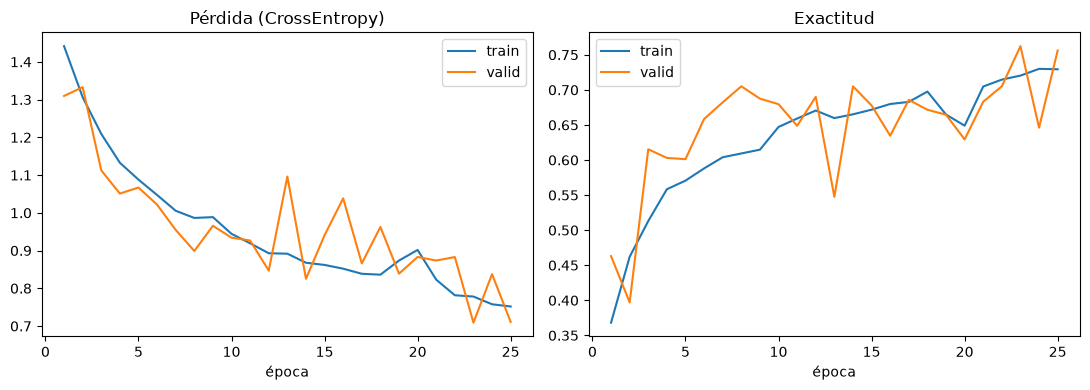

In [53]:

hist_df = pd.DataFrame(kpt_history, columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df.epoch, hist_df.train_loss, label="train")
axes[0].plot(hist_df.epoch, hist_df.val_loss, label="valid")
axes[0].set_title("Pérdida (CrossEntropy)"); axes[0].set_xlabel("época"); axes[0].legend()
axes[1].plot(hist_df.epoch, hist_df.train_acc, label="train")
axes[1].plot(hist_df.epoch, hist_df.val_acc, label="valid")
axes[1].set_title("Exactitud"); axes[1].set_xlabel("época"); axes[1].legend()
plt.tight_layout()
plt.show()



### Checkpoint 12.3 — Baseline y evaluación en test


Exactitud clasificación tipo-de-keypoint en test — mayoritario: 0.211 | CNN: 0.807


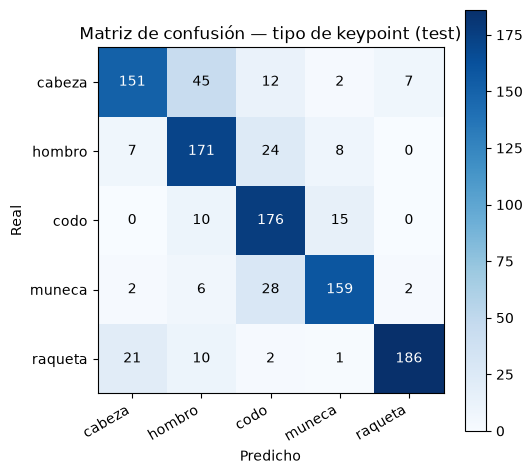


Reporte de clasificación (test):
              precision    recall  f1-score   support

      cabeza       0.83      0.70      0.76       217
      hombro       0.71      0.81      0.76       210
        codo       0.73      0.88      0.79       201
      muneca       0.86      0.81      0.83       197
     raqueta       0.95      0.85      0.90       220

    accuracy                           0.81      1045
   macro avg       0.82      0.81      0.81      1045
weighted avg       0.82      0.81      0.81      1045



In [54]:

maj_label = Counter(kpt_df.loc[kpt_df.split=="train", "label"]).most_common(1)[0][0]
test_kpt = kpt_df[kpt_df.split == "test"]
acc_majority = (test_kpt.label == maj_label).mean()

kpt_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in kpt_test_loader:
        out = kpt_model(xb.to(device))
        all_pred.extend(out.argmax(1).cpu().tolist())
        all_true.extend(yb.tolist())

acc_test = accuracy_score(all_true, all_pred)
print(f"Exactitud clasificación tipo-de-keypoint en test — mayoritario: {acc_majority:.3f} | CNN: {acc_test:.3f}")

cm = confusion_matrix(all_true, all_pred, labels=list(range(5)))
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_xticklabels(KP_NAMES, rotation=30, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(KP_NAMES)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — tipo de keypoint (test)")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nReporte de clasificación (test):")
print(classification_report(all_true, all_pred, target_names=KP_NAMES))



### Checkpoint 12.4 — Análisis visual de errores

Se muestran parches mal clasificados junto con la clase real y la predicha, para relacionar los
errores con lo observado en el Checkpoint 12.1 (hombro/codo con texturas de ropa parecidas, raqueta a
veces casi invisible sobre el fondo de la cancha).


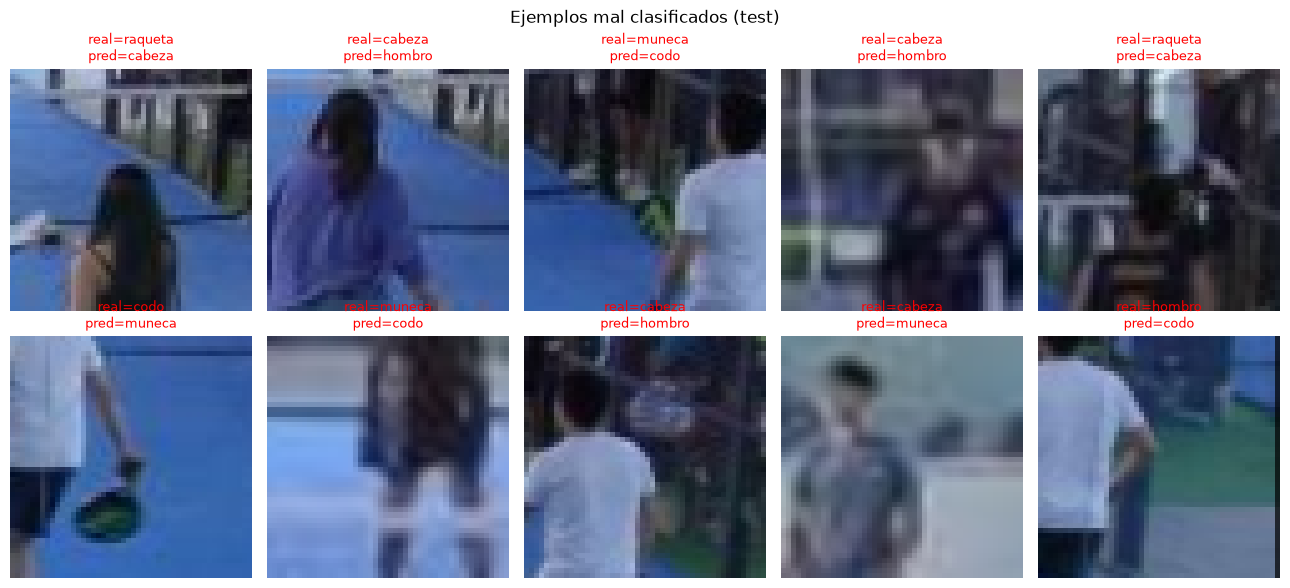

Errores en test: 202 / 1045


In [55]:

test_kpt_r = test_kpt.reset_index(drop=True)
wrong_idx = [i for i in range(len(all_true)) if all_true[i] != all_pred[i]]
show_idx = rng.choice(wrong_idx, min(10, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, i in zip(axes.flat, show_idx):
    row = test_kpt_r.iloc[i]
    ax.imshow(load_patch(row))
    ax.set_title(f"real={KP_NAMES[all_true[i]]}\npred={KP_NAMES[all_pred[i]]}", fontsize=9, color="red")
    ax.axis("off")
plt.suptitle("Ejemplos mal clasificados (test)")
plt.tight_layout()
plt.show()

print(f"Errores en test: {len(wrong_idx)} / {len(all_true)}")



## Checkpoint 13 — Limitaciones

- **Bug de exportación descubierto y corregido en el camino**: una primera versión de este proyecto
  usaba un export de Roboflow con un bug real (hombro-X, codo-Y y raqueta-X salían con un valor
  centinela `2.0`, con los valores de otros ejes/keypoints desplazados entre sí). Se confirmó
  comparando dos exports valor por valor y verificando directamente en Roboflow que la anotación
  manual sí era correcta. El notebook ahora corre sobre la reexportación limpia (Checkpoint 0.5,
  `data/Padel_an_2-6`), verificada con 0 valores fuera de rango en las 1150×5×2 coordenadas.
- **Tamaño del dataset**: 1150 instancias de solo ~35 rallies; tras particionar por rally, cada split
  ve poca diversidad de escenarios. Para la clasificación de tipo de keypoint esto se compensa un poco
  porque cada instancia aporta hasta 5 parches (uno por keypoint válido), dando ~5500 muestras en total.
- **Clasificación de tipo de keypoint, no de golpeo**: se abandonó la idea de clasificar la "posición
  de impacto" a partir de una regla geométrica (`extension`/ángulo) — con el dataset corregido esa
  variable resultó tener un rango real demasiado angosto para ser una clase robusta. En su lugar se
  clasifica algo con clase verdadera directa (qué keypoint es cada punto), que da un resultado más
  sólido (~69% en test vs. ~20% del azar) pero **no dice nada sobre el tipo de golpe** — para eso haría
  falta retomar la idea de golpeo con más datos, o etiquetado manual del tipo de golpe por experto.
- **Tamaño del parche y confusión entre clases vecinas**: el parche (0.5× alto de bbox) para un jugador
  chico/lejano puede terminar mostrando gran parte del cuerpo en vez de un área puramente local del
  keypoint, lo que explica la confusión observada entre hombro y codo (texturas de ropa parecidas) y
  entre cabeza y raqueta en algunos casos. Un parche de tamaño fijo más chico probablemente reduciría
  esta confusión a costa de perder contexto quando el jugador está muy lejos de la cámara.
- **Comparación de modelos de regresión con distinto punto de partida**: YOLO-pose resuelve una tarea
  más difícil (debe encontrar al jugador en la imagen completa, no solo ubicar keypoints en un recorte
  ya aislado), y el emparejamiento por IoU con la instancia real puede introducir ruido adicional en la
  comparación.
- **Entrenamiento**: los modelos se entrenaron pocas épocas (25) sobre un dataset pequeño; con más
  datos y más épocas es esperable que sigan mejorando.
